# Benin — Solar Data EDA
**MoonLight Energy Solutions | Task 2**

Branch: `eda-benin`

**Objective:** Profile, clean, and explore the Benin solar dataset end-to-end
so it is ready for cross-country comparison.

**References:**
- [Solar Radiation Measurement Data](https://energydata.info/dataset/?q=Solar+Radiation+Measurement&vocab_regions=AFR)
- Duffie & Beckman (2013). *Solar Engineering of Thermal Processes*. Wiley.
- [Pandas docs — resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html)
- [Windrose Python library](https://python-windrose.github.io/windrose/)
- [Seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## 1. Imports & Configuration

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Optional: windrose (pip install windrose)
try:
    from windrose import WindroseAxes
    HAS_WINDROSE = True
except ImportError:
    HAS_WINDROSE = False
    print("windrose not installed — falling back to polar bar chart")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

# ── Constants ────────────────────────────────────────────────────────────────
COUNTRY = "benin"
RAW_FILE = "E:/project 2026/Cross-Country-Solar-Farm-Analysis/data/benin-malanville.csv"
CLEAN_FILE = f"E:/project 2026/Cross-Country-Solar-Farm-Analysis/data/{COUNTRY}_clean.csv"
IRRAD_COLS = ["GHI", "DNI", "DHI"]
SENSOR_COLS = ["ModA", "ModB"]
WIND_COLS = ["WS", "WSgust"]
Z_SCORE_COLS = IRRAD_COLS + SENSOR_COLS + WIND_COLS
Z_THRESHOLD = 3.0
NULL_THRESHOLD = 0.05
print(f"Country  : {COUNTRY}")
print(f"Raw file : {RAW_FILE}")

Country  : benin
Raw file : E:/project 2026/Cross-Country-Solar-Farm-Analysis/data/benin-malanville.csv


## 2. Load Data

In [2]:
df_raw = pd.read_csv(RAW_FILE)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"])
df_raw = df_raw.set_index("Timestamp").sort_index()

print(f"Shape   : {df_raw.shape}")
print(f"Period  : {df_raw.index.min()} → {df_raw.index.max()}")
print(f"\nData types:\n{df_raw.dtypes}")
df_raw.head(3)

Shape   : (525600, 18)
Period  : 2021-08-09 00:01:00 → 2022-08-09 00:00:00

Data types:
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN


## 3. Summary Statistics & Missing-Value Report

`df.describe()` gives a statistical overview of all numeric columns.
We then audit for nulls and flag any column with > 5% missing values.

In [3]:
print("=== DESCRIPTIVE STATISTICS ===")
display(df_raw.describe().T.round(3))

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
GHI,525600.0,240.559,331.131,-12.9,-2.0,1.8,483.4,1413.0
DNI,525600.0,167.188,261.711,-7.8,-0.5,-0.1,314.2,952.3
DHI,525600.0,115.359,158.691,-12.6,-2.1,1.6,216.3,759.2
ModA,525600.0,236.589,326.895,0.0,0.0,4.5,463.7,1342.3
ModB,525600.0,228.884,316.537,0.0,0.0,4.3,447.9,1342.3
Tamb,525600.0,28.180,5.924,11.0,24.2,28.0,32.3,43.8
RH,525600.0,54.488,28.073,2.1,28.8,55.1,80.1,100.0
WS,525600.0,2.121,1.603,0.0,1.0,1.9,3.1,19.5
WSgust,525600.0,2.809,2.029,0.0,1.3,2.6,4.1,26.6
WSstdev,525600.0,0.473,0.273,0.0,0.4,0.5,0.6,4.2


In [4]:
# Missing value report
null_counts = df_raw.isna().sum()
null_pct    = null_counts / len(df_raw)
null_report = pd.DataFrame({
    "Null Count": null_counts,
    "Null %":     (null_pct * 100).round(2),
    "Flagged (>5%)": null_pct > NULL_THRESHOLD,
})
print("=== MISSING VALUE REPORT ===")
display(null_report[null_report["Null Count"] > 0])
print(f"\nColumns flagged (>{NULL_THRESHOLD*100:.0f}% nulls):",
      list(null_report[null_report["Flagged (>5%)"]].index))

=== MISSING VALUE REPORT ===


,Null Count,Null %,Flagged (>5%)
Comments,525600,100.0,True



Columns flagged (>5% nulls): ['Comments']


## 4. Outlier Detection & Basic Cleaning

**Strategy:**
1. Clamp physically impossible negative irradiance values to 0.
2. Compute Z-scores for `GHI, DNI, DHI, ModA, ModB, WS, WSgust`.
3. Flag rows where any column has |Z| > 3.
4. Impute medians for remaining nulls in key columns.
5. Drop confirmed outlier rows.

**Statistical rationale:** Z-score > 3 captures observations more than 3
standard deviations from the mean — typically <0.3% of a normally distributed
variable. For skewed distributions (like irradiance), this is a conservative
but effective first-pass filter.

In [5]:
df = df_raw.copy()

# 1. Physical bounds
for col in IRRAD_COLS + SENSOR_COLS:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        if neg:
            print(f"[{col}] clamping {neg} negative values to 0")
        df[col] = df[col].clip(lower=0)

# 2. Z-score outlier flagging
cols_for_z = [c for c in Z_SCORE_COLS if c in df.columns]
z_scores   = df[cols_for_z].apply(stats.zscore, nan_policy="omit")
outlier_mask = (z_scores.abs() > Z_THRESHOLD).any(axis=1)
print(f"\nOutlier rows (|Z| > {Z_THRESHOLD}): {outlier_mask.sum()} "
      f"({outlier_mask.mean():.2%})")

# 3. Impute medians for key columns BEFORE dropping outliers
key_cols = IRRAD_COLS + SENSOR_COLS + WIND_COLS + ["Tamb", "RH", "BP"]
for col in [c for c in key_cols if c in df.columns]:
    n_null = df[col].isna().sum()
    if n_null:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"[{col}] imputed {n_null} nulls → median={med:.3f}")

# 4. Drop outlier rows
df_clean = df[~outlier_mask].copy()
print(f"\nRows after cleaning : {len(df_clean):,}  "
      f"(removed {outlier_mask.sum():,} rows, {outlier_mask.mean():.2%})")

[GHI] clamping 258847 negative values to 0
[DNI] clamping 275987 negative values to 0
[DHI] clamping 259182 negative values to 0

Outlier rows (|Z| > 3.0): 7893 (1.50%)

Rows after cleaning : 517,707  (removed 7,893 rows, 1.50%)


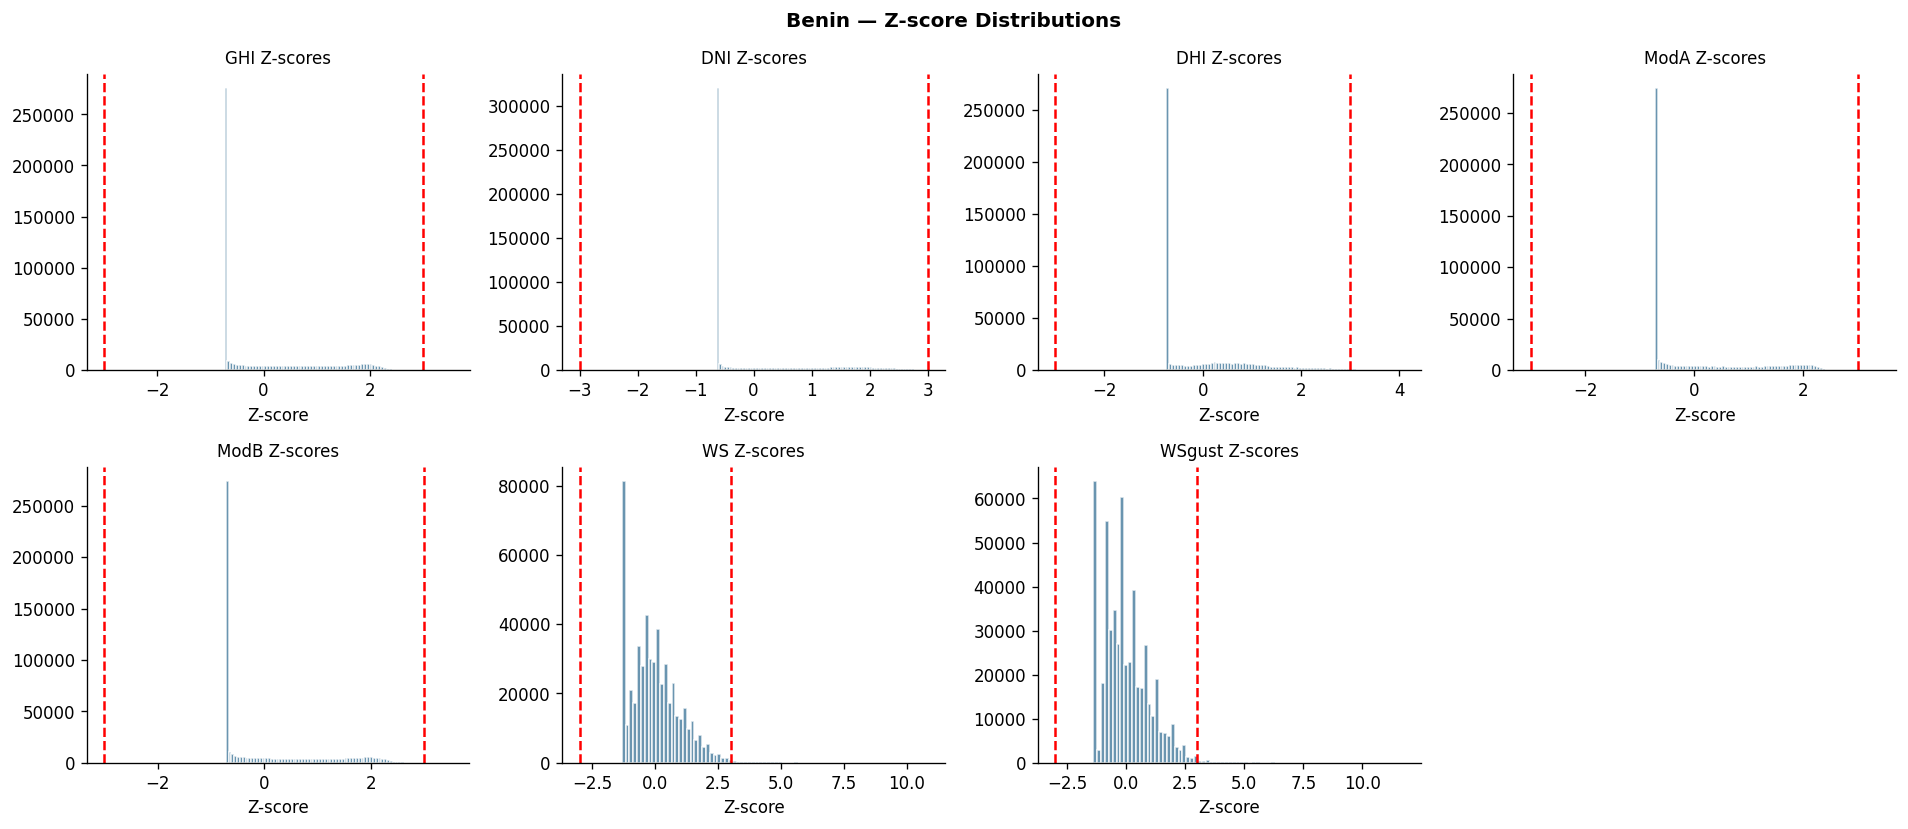

In [6]:
# Visual: Z-score distributions for key columns
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(cols_for_z):
    ax = axes[i]
    z  = z_scores[col].dropna()
    ax.hist(z, bins=80, color="#457B9D", edgecolor="white", alpha=0.8)
    ax.axvline( Z_THRESHOLD, color="red",  lw=1.5, ls="--", label=f"+{Z_THRESHOLD}")
    ax.axvline(-Z_THRESHOLD, color="red",  lw=1.5, ls="--", label=f"-{Z_THRESHOLD}")
    ax.set_title(f"{col} Z-scores", fontsize=10)
    ax.set_xlabel("Z-score")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(f"{COUNTRY.title()} — Z-score Distributions", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Export Cleaned Dataset

In [7]:
# Drop fully-null Comments column if present
if "Comments" in df_clean.columns and df_clean["Comments"].isna().all():
    df_clean = df_clean.drop(columns=["Comments"])

df_clean.to_csv(CLEAN_FILE)
print(f"✓ Exported → {CLEAN_FILE}  ({len(df_clean):,} rows × {df_clean.shape[1]} cols)")

✓ Exported → E:/project 2026/Cross-Country-Solar-Farm-Analysis/data/benin_clean.csv  (517,707 rows × 17 cols)


## 6. Time Series Analysis

We visualise GHI, DNI, DHI, and Tamb over time to identify:
- **Seasonal patterns** (dry vs. wet season irradiance)
- **Diurnal patterns** (mid-day peaks)
- **Anomalies** (sudden drops, sensor faults)

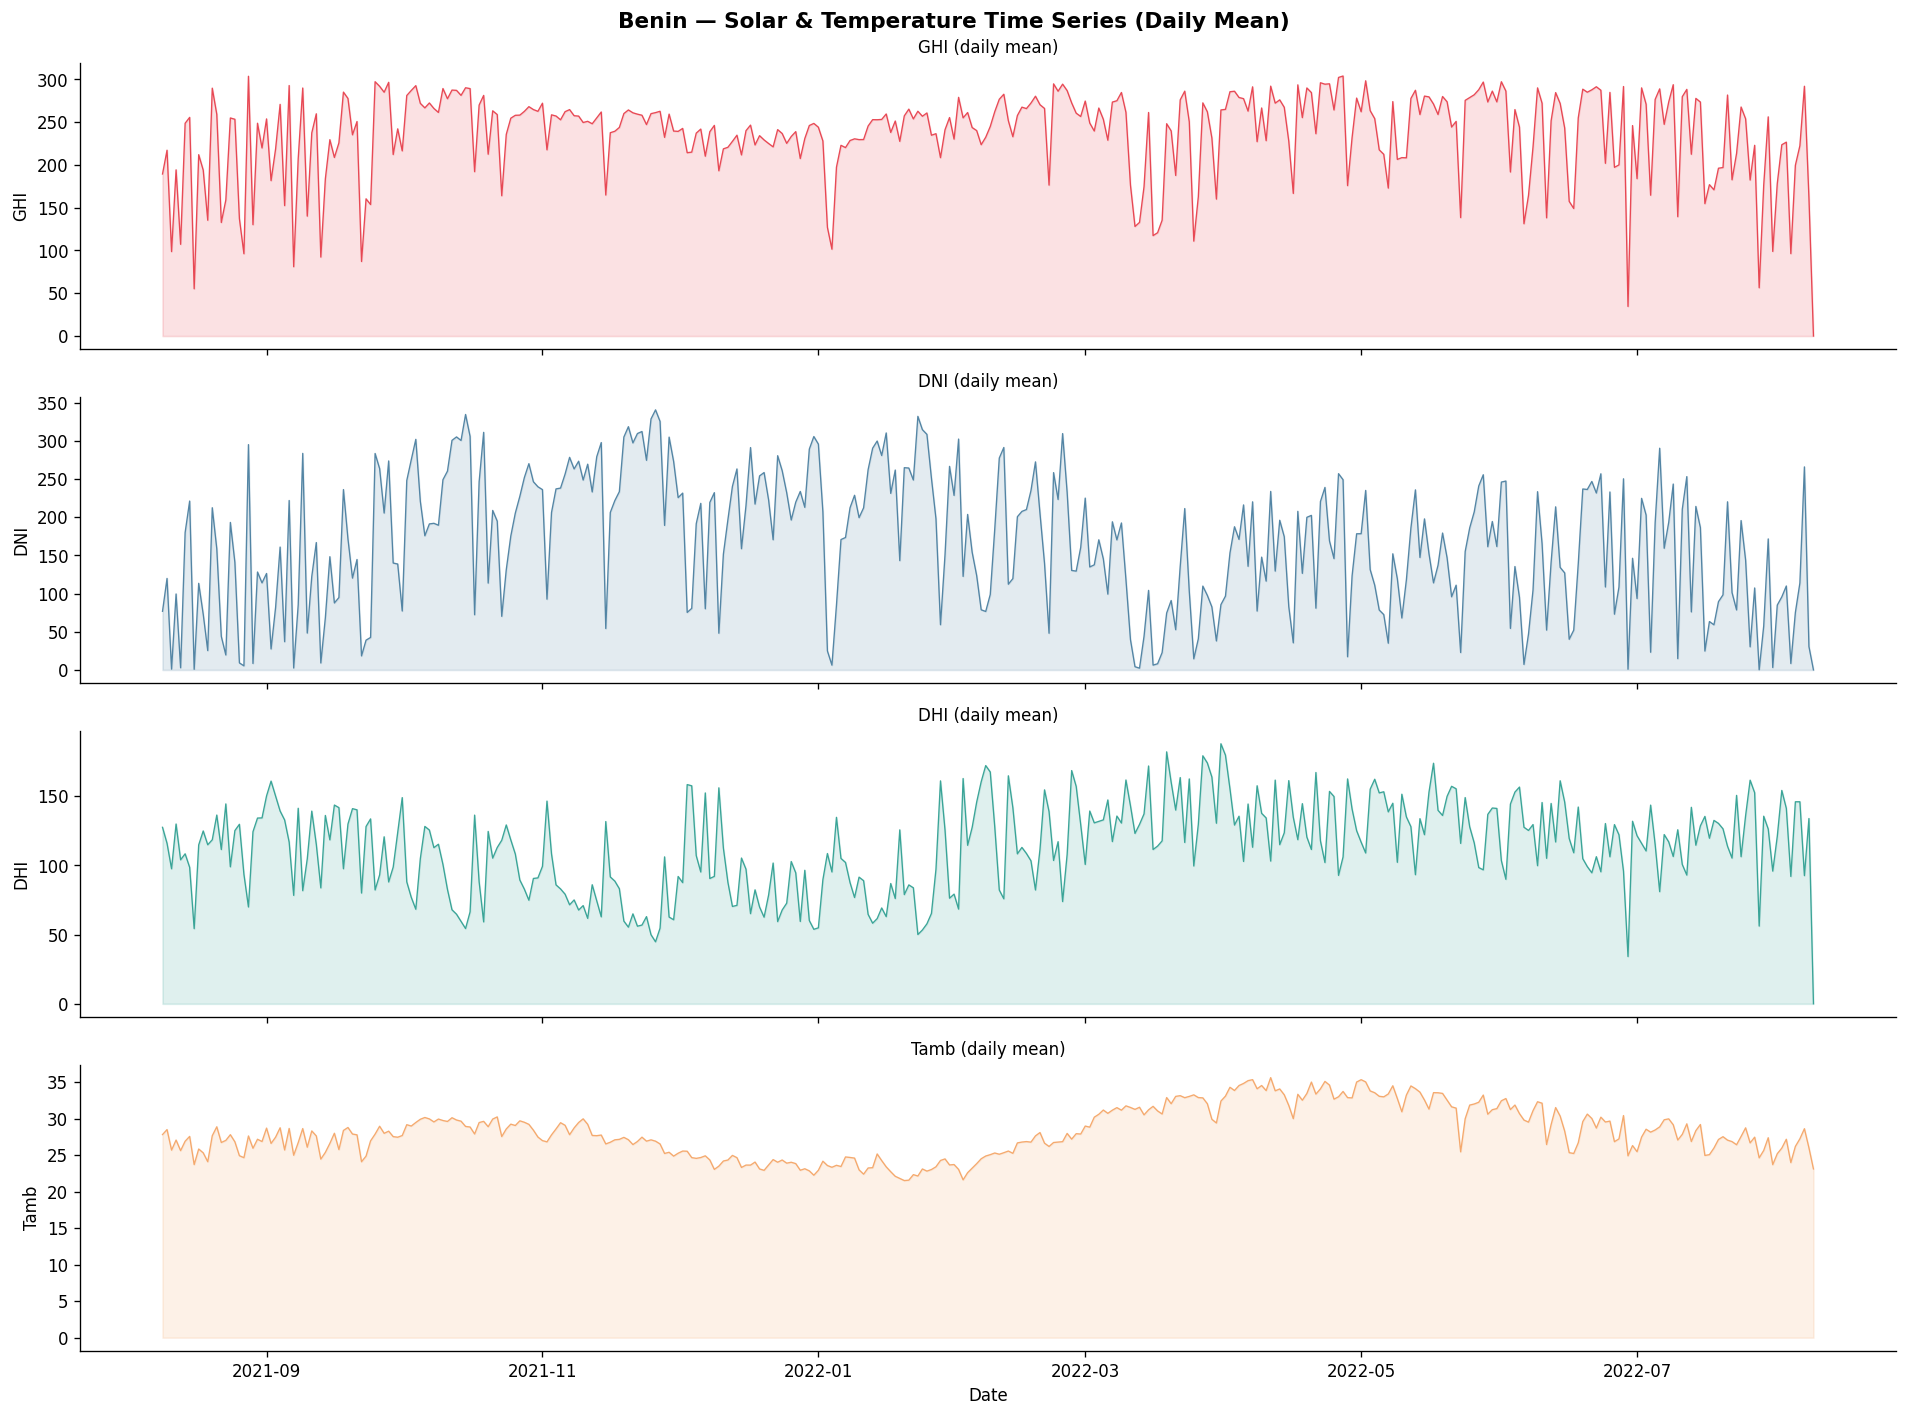

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
plot_cols  = [c for c in ["GHI", "DNI", "DHI", "Tamb"] if c in df_clean.columns]
colors     = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261"]

for ax, col, color in zip(axes, plot_cols, colors):
    daily = df_clean[col].resample("D").mean()
    ax.plot(daily.index, daily.values, color=color, lw=0.8, alpha=0.9)
    ax.fill_between(daily.index, daily.values, alpha=0.15, color=color)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(f"{col} (daily mean)", fontsize=10)

axes[-1].set_xlabel("Date")
fig.suptitle(f"{COUNTRY.title()} — Solar & Temperature Time Series (Daily Mean)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

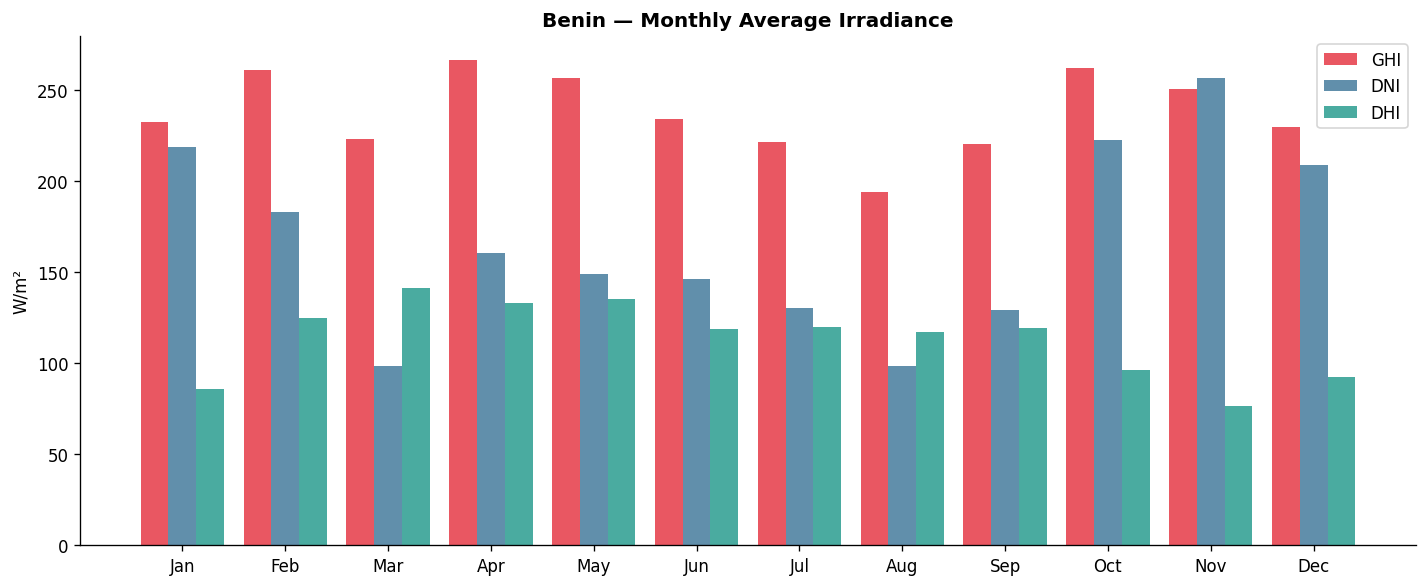

In [9]:
# Monthly average pattern
df_clean["Month"] = df_clean.index.month
monthly = df_clean.groupby("Month")[["GHI", "DNI", "DHI"]].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12)
w = 0.27
ax.bar(x - w, monthly["GHI"],  w, label="GHI",  color="#E63946", alpha=0.85)
ax.bar(x,     monthly["DNI"],  w, label="DNI",  color="#457B9D", alpha=0.85)
ax.bar(x + w, monthly["DHI"],  w, label="DHI",  color="#2A9D8F", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel("W/m²")
ax.set_title(f"{COUNTRY.title()} — Monthly Average Irradiance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

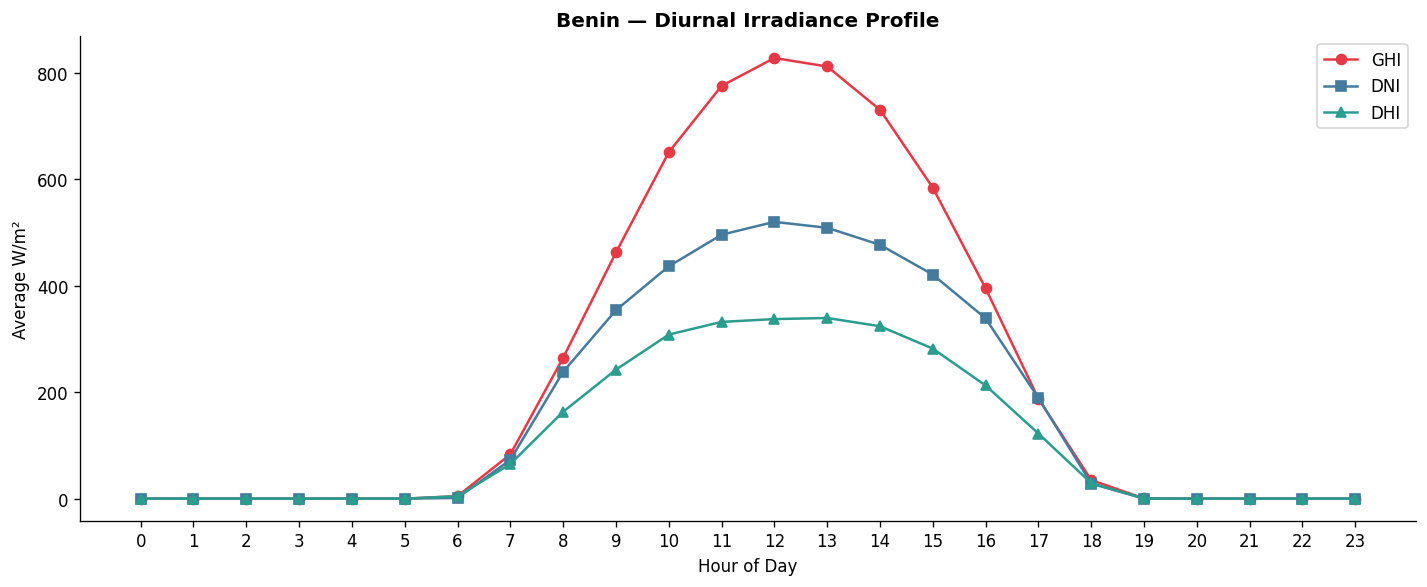

In [10]:
# Diurnal profile (hour-of-day)
df_clean["Hour"] = df_clean.index.hour
hourly = df_clean.groupby("Hour")[["GHI", "DNI", "DHI"]].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly["GHI"], "o-", color="#E63946", label="GHI")
ax.plot(hourly.index, hourly["DNI"], "s-", color="#457B9D", label="DNI")
ax.plot(hourly.index, hourly["DHI"], "^-", color="#2A9D8F", label="DHI")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average W/m²")
ax.set_title(f"{COUNTRY.title()} — Diurnal Irradiance Profile", fontweight="bold")
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 7. Cleaning Impact

Compare average ModA and ModB readings before and after cleaning events.
A positive lift post-cleaning confirms soiling losses are material.

,ModA,ModB
Not Cleaned (0),232.172,224.811
Cleaned (1),306.610,301.450


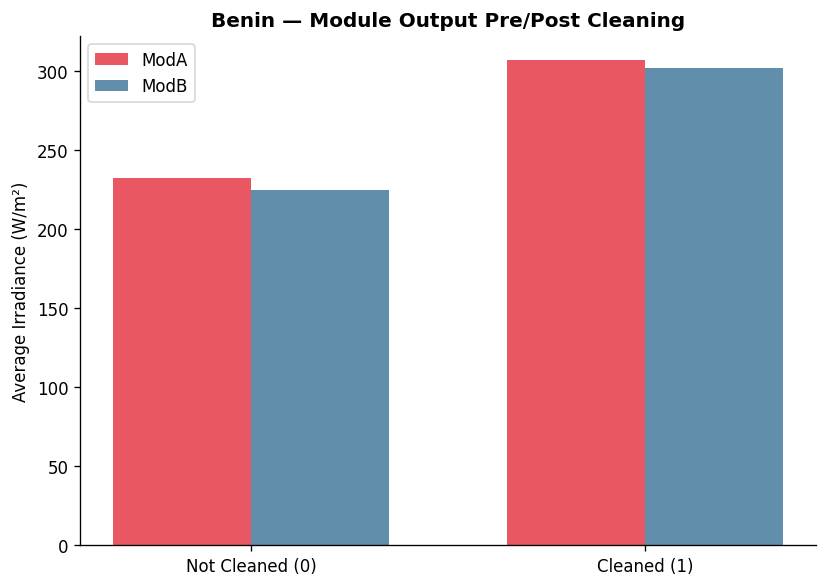

In [11]:
if "Cleaning" in df_clean.columns:
    grp = df_clean.groupby("Cleaning")[["ModA", "ModB"]].mean()
    grp.index = ["Not Cleaned (0)", "Cleaned (1)"]
    display(grp.round(3))

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(2)
    w = 0.35
    ax.bar(x - w/2, grp["ModA"], w, label="ModA", color="#E63946", alpha=0.85)
    ax.bar(x + w/2, grp["ModB"], w, label="ModB", color="#457B9D", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(grp.index)
    ax.set_ylabel("Average Irradiance (W/m²)")
    ax.set_title(f"{COUNTRY.title()} — Module Output Pre/Post Cleaning",
                 fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'Cleaning' column found in dataset.")

## 8. Correlation & Relationship Analysis

### 8a. Correlation Heatmap
A Pearson correlation matrix reveals linear dependencies between irradiance
components, module temperatures, and environmental factors.

**Expected patterns:**
- GHI ↔ DNI: strong positive (direct radiation dominates on clear days)
- GHI ↔ RH: negative (cloud cover = humidity ↑, solar ↓)
- GHI ↔ Tamb: moderate positive (sunnier days are warmer)

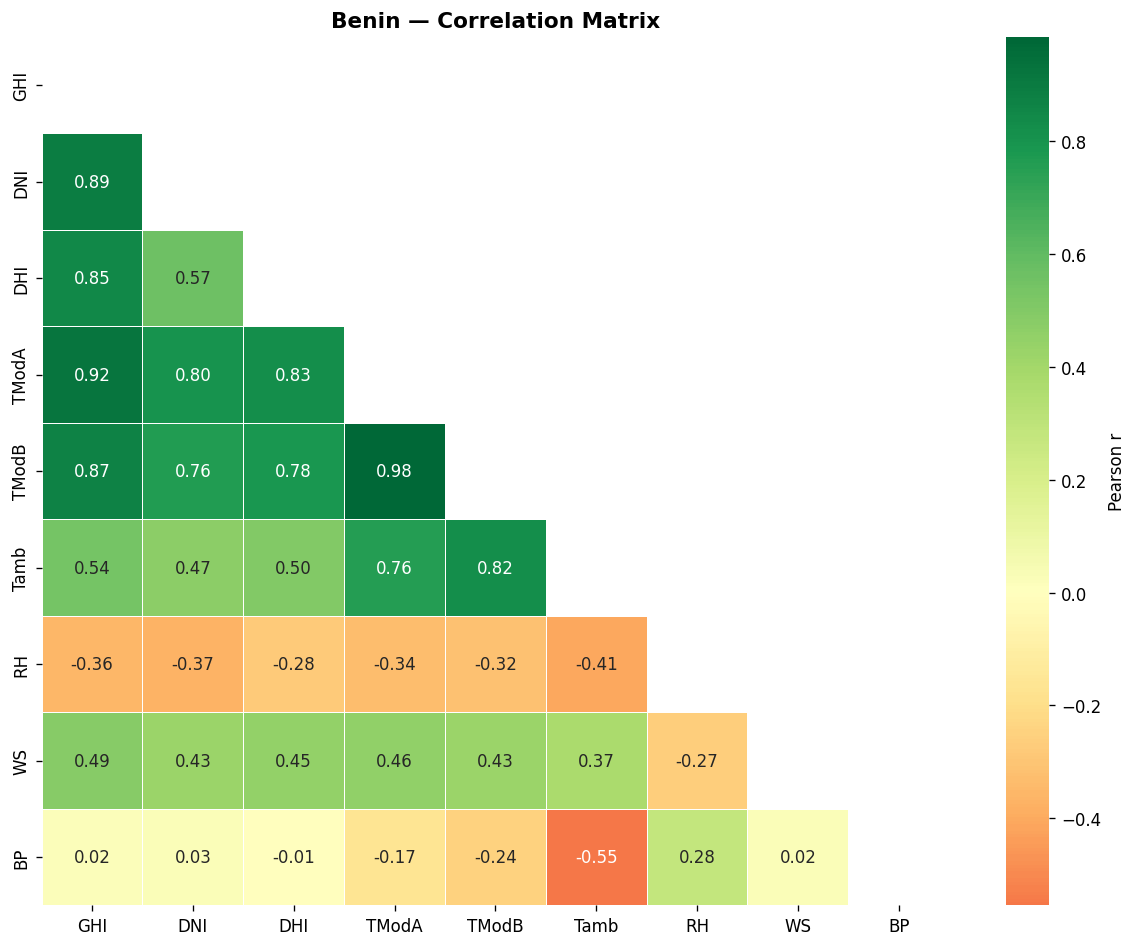

In [12]:
corr_cols = [c for c in ["GHI","DNI","DHI","TModA","TModB","Tamb","RH","WS","BP"]
             if c in df_clean.columns]
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, mask=mask, linewidths=0.5,
            cbar_kws={"label": "Pearson r"})
ax.set_title(f"{COUNTRY.title()} — Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 8b. Scatter Plots: Wind vs GHI and RH vs Tamb

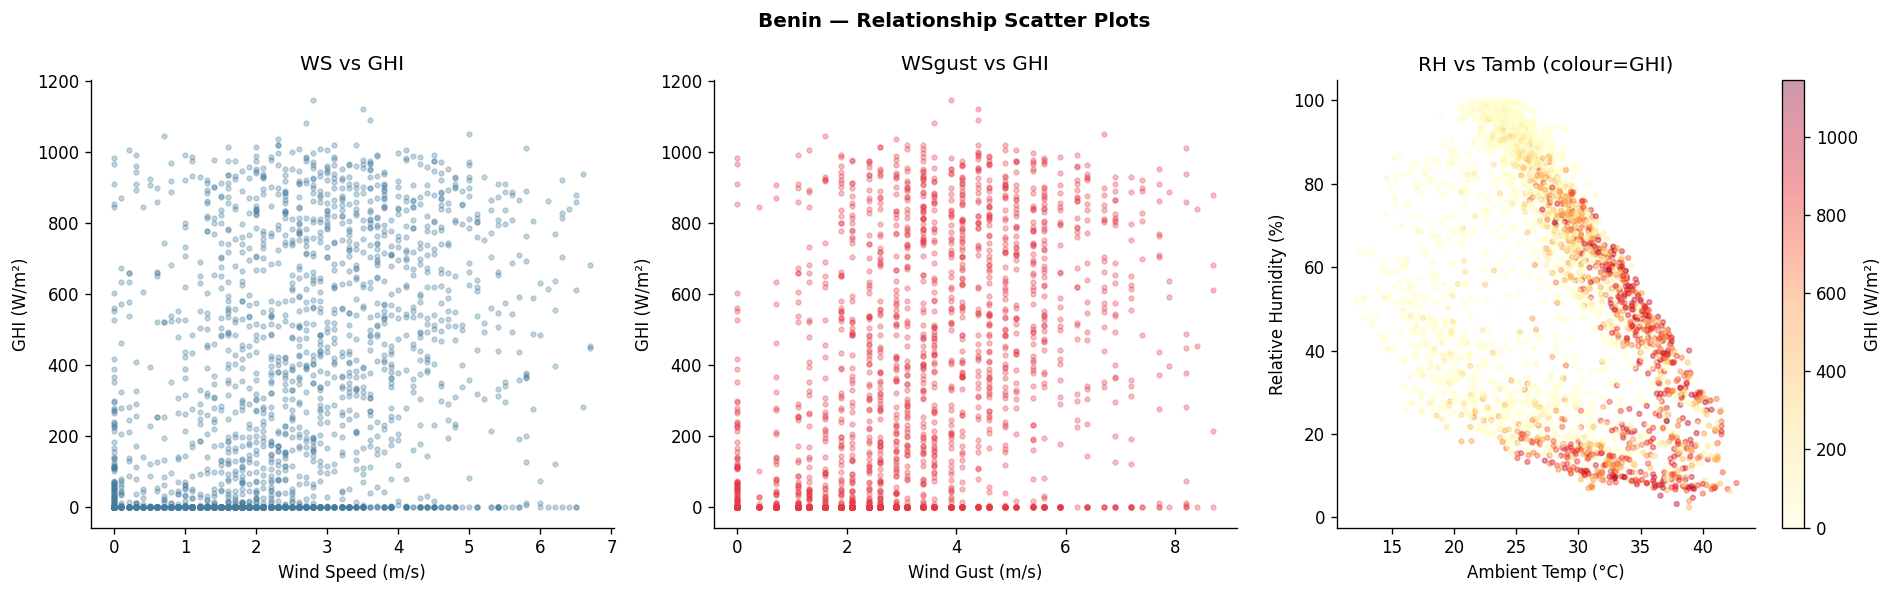

In [13]:
sample = df_clean.sample(min(3000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# WS vs GHI
axes[0].scatter(sample["WS"], sample["GHI"], alpha=0.3, s=8, color="#457B9D")
axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("GHI (W/m²)")
axes[0].set_title("WS vs GHI")

# WSgust vs GHI
if "WSgust" in sample.columns:
    axes[1].scatter(sample["WSgust"], sample["GHI"], alpha=0.3, s=8, color="#E63946")
    axes[1].set_xlabel("Wind Gust (m/s)")
    axes[1].set_ylabel("GHI (W/m²)")
    axes[1].set_title("WSgust vs GHI")

# RH vs Tamb
sc = axes[2].scatter(sample["Tamb"], sample["RH"],
                     c=sample["GHI"], cmap="YlOrRd",
                     alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[2], label="GHI (W/m²)")
axes[2].set_xlabel("Ambient Temp (°C)")
axes[2].set_ylabel("Relative Humidity (%)")
axes[2].set_title("RH vs Tamb (colour=GHI)")

fig.suptitle(f"{COUNTRY.title()} — Relationship Scatter Plots",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Wind & Distribution Analysis

C:\Windows\Temp\ipykernel_22280\2603096170.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


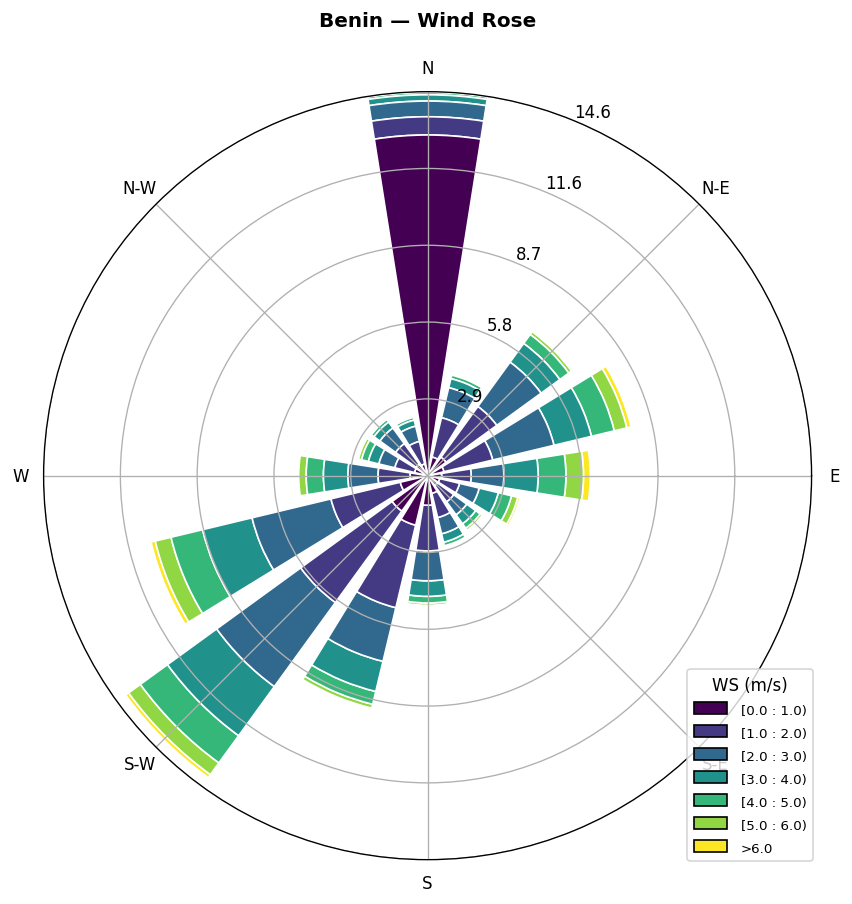

In [14]:
# Wind Rose
if HAS_WINDROSE and "WD" in df_clean.columns:
    fig = plt.figure(figsize=(8, 8))
    ax  = WindroseAxes.from_ax(fig=fig)
    ax.bar(df_clean["WD"].dropna(), df_clean["WS"].dropna(),
           normed=True, opening=0.8, edgecolor="white",
           bins=np.arange(0, df_clean["WS"].max(), 1))
    ax.set_legend(title="WS (m/s)", loc="lower right")
    ax.set_title(f"{COUNTRY.title()} — Wind Rose", fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()
else:
    # Fallback: polar bar
    if "WD" in df_clean.columns:
        bins   = np.arange(0, 361, 22.5)
        labels = bins[:-1]
        d      = df_clean[["WD","WS"]].dropna().copy()
        d["sector"] = pd.cut(d["WD"], bins=bins, labels=labels, include_lowest=True)
        agg = d.groupby("sector", observed=True)["WS"].mean()
        theta = np.deg2rad(agg.index.astype(float))
        fig = plt.figure(figsize=(8, 8))
        ax  = fig.add_subplot(111, projection="polar")
        bars = ax.bar(theta, agg.values, width=np.deg2rad(22.5),
                      bottom=0, color=plt.cm.Blues(agg.values / agg.max()),
                      edgecolor="white", alpha=0.85)
        ax.set_title(f"{COUNTRY.title()} — Wind Rose (avg WS by sector)",
                     fontweight="bold", pad=20)
        plt.tight_layout()
        plt.show()

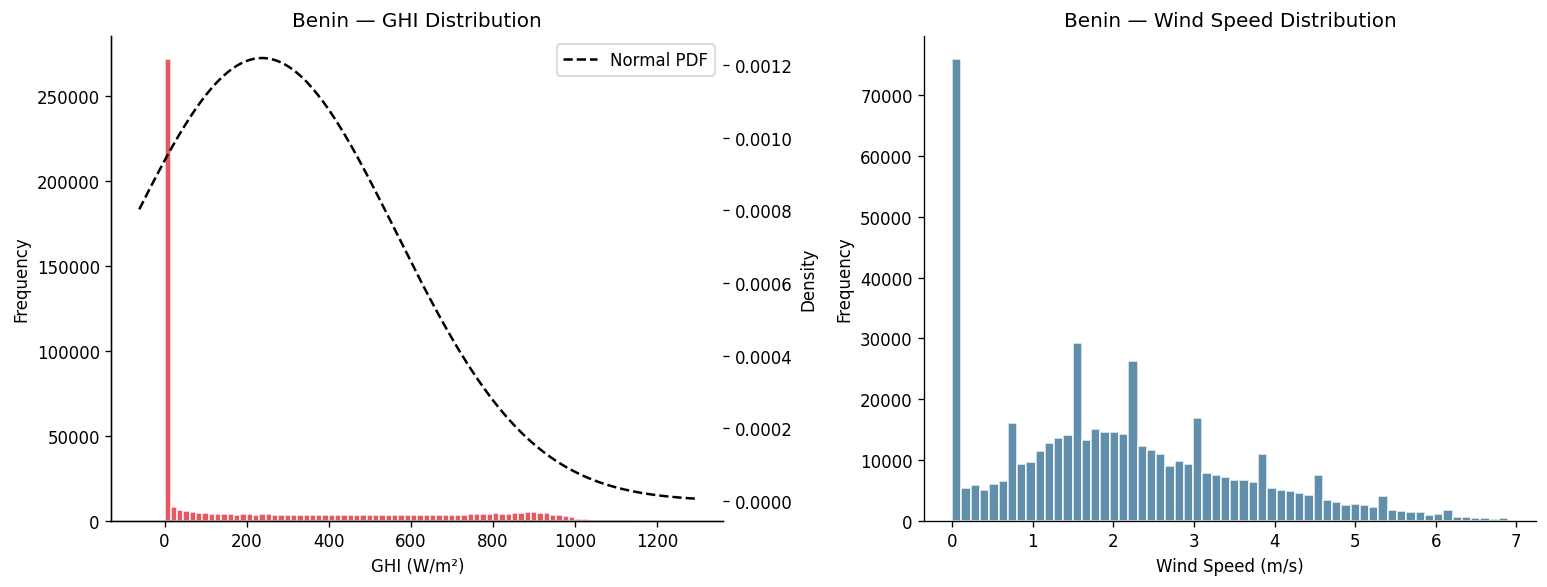

GHI — mean: 237.48, std: 327.17, skewness: 1.060, kurtosis: -0.385


In [15]:
# Histograms: GHI and WS
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_clean["GHI"].dropna(), bins=80, color="#E63946",
             edgecolor="white", alpha=0.85)
axes[0].set_xlabel("GHI (W/m²)")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"{COUNTRY.title()} — GHI Distribution")

axes[1].hist(df_clean["WS"].dropna(), bins=60, color="#457B9D",
             edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Wind Speed (m/s)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"{COUNTRY.title()} — Wind Speed Distribution")

# Overlay normal curve on GHI
ghi = df_clean["GHI"].dropna()
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, ghi.mean(), ghi.std())
ax2 = axes[0].twinx()
ax2.plot(x, p, "k--", lw=1.5, label="Normal PDF")
ax2.set_ylabel("Density")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"GHI — mean: {ghi.mean():.2f}, std: {ghi.std():.2f}, "
      f"skewness: {stats.skew(ghi):.3f}, kurtosis: {stats.kurtosis(ghi):.3f}")

## 10. Temperature & Humidity Analysis

Relative humidity (RH) mediates the relationship between temperature and
solar radiation. On humid days, cloud cover increases, scattering and
absorbing incoming solar radiation before it reaches the panels.

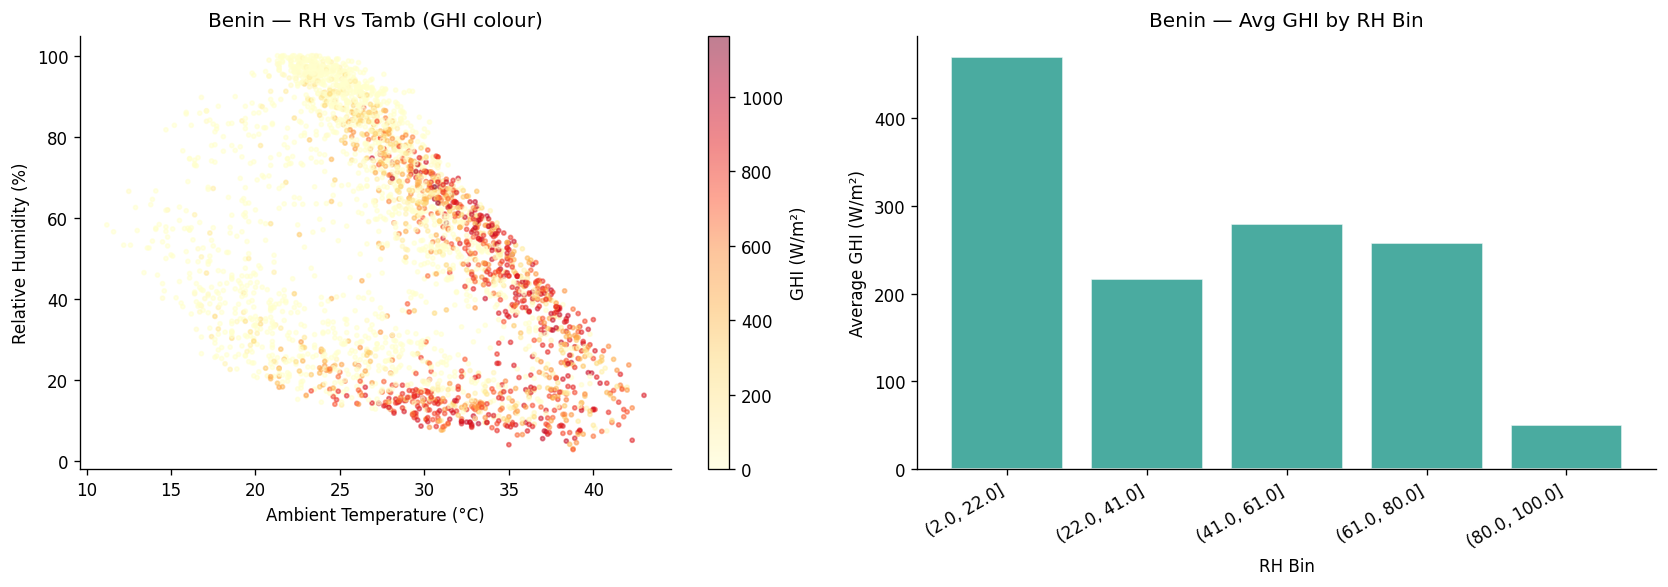

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RH vs Tamb
sample = df_clean.sample(min(3000, len(df_clean)), random_state=10)
sc = axes[0].scatter(sample["Tamb"], sample["RH"],
                     c=sample["GHI"], cmap="YlOrRd", s=6, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="GHI (W/m²)")
axes[0].set_xlabel("Ambient Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].set_title(f"{COUNTRY.title()} — RH vs Tamb (GHI colour)")

# RH vs GHI (box-binned)
df_clean["RH_bin"] = pd.cut(df_clean["RH"], bins=5, precision=0)
rh_grp = df_clean.groupby("RH_bin", observed=True)["GHI"].mean()
axes[1].bar(range(len(rh_grp)), rh_grp.values, color="#2A9D8F", edgecolor="white",
            alpha=0.85)
axes[1].set_xticks(range(len(rh_grp)))
axes[1].set_xticklabels([str(b) for b in rh_grp.index], rotation=30, ha="right")
axes[1].set_ylabel("Average GHI (W/m²)")
axes[1].set_xlabel("RH Bin")
axes[1].set_title(f"{COUNTRY.title()} — Avg GHI by RH Bin")

plt.tight_layout()
plt.show()

## 11. Bubble Chart — GHI vs Tamb (bubble = RH or BP)

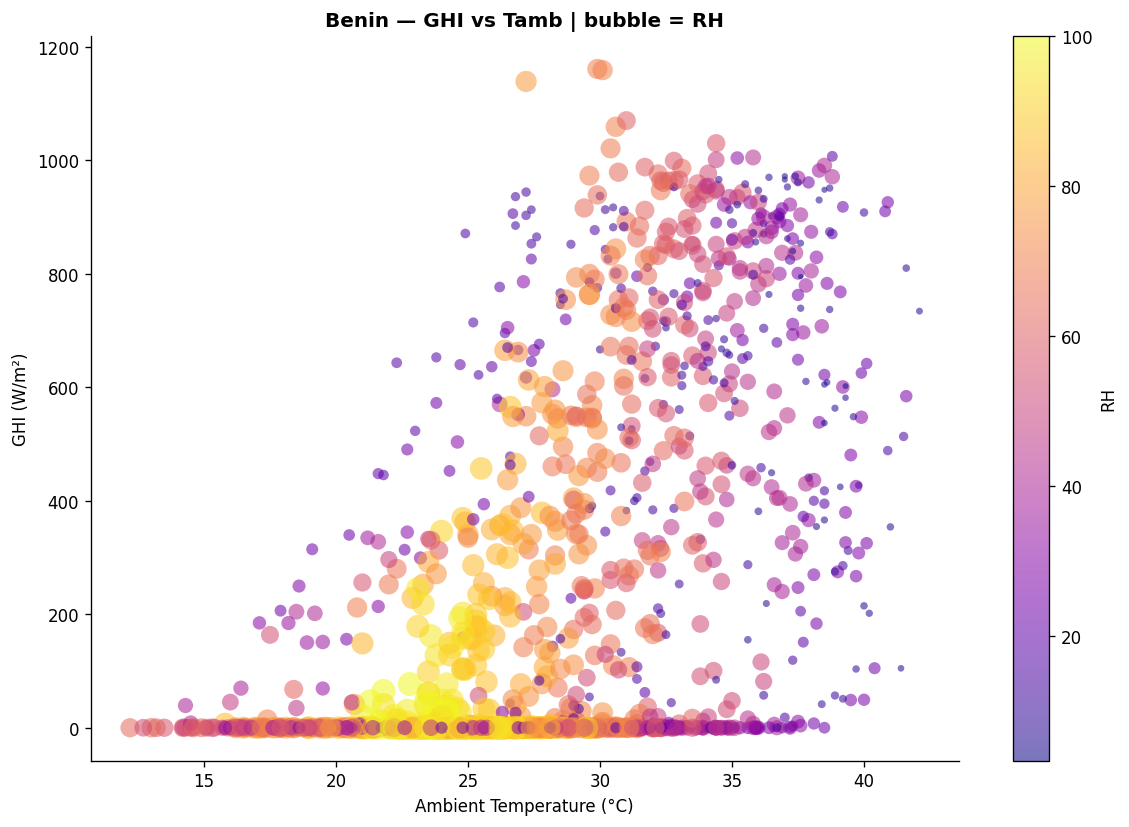

In [17]:
bubble_col = "RH"  # change to "BP" if preferred
sample = df_clean[["GHI", "Tamb", bubble_col]].dropna()
sample = sample.sample(min(1500, len(sample)), random_state=5)
size_norm = (sample[bubble_col] - sample[bubble_col].min()) /             (sample[bubble_col].max() - sample[bubble_col].min()) * 200 + 10

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sample["Tamb"], sample["GHI"],
                s=size_norm, c=sample[bubble_col],
                cmap="plasma", alpha=0.55, edgecolors="none")
plt.colorbar(sc, ax=ax, label=f"{bubble_col}")
ax.set_xlabel("Ambient Temperature (°C)")
ax.set_ylabel("GHI (W/m²)")
ax.set_title(f"{COUNTRY.title()} — GHI vs Tamb | bubble = {bubble_col}",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 12. Key Insights Summary

*Fill in after reviewing the plots above.*

- **Insight 1 — Peak Irradiance Period:**
- **Insight 2 — Cleaning Effect:**
- **Insight 3 — Humidity Impact:**

---
*End of EDA notebook — Benin*